In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv("finalized_players.csv")

df = df.drop(columns=['Player Name'])  # 'Player Name' is just an identifier

# Handle categorical variables using one-hot encoding
categorical_cols = ['Pos', 'Squad', 'League', 'Season']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Handle missing values (fill with median values)
df = df.fillna(df.median())

selected_columns = [
    'Tkl', 'Tkl%', 'Tkl+Int', 'Int', 'Blocks', 'Clr', 'Def 3rd', 'Mid 3rd',
    'Won%', 'Lost', 'Err', 'Sh', 'Pass', 'Att', 'Att 3rd', '90s'
]

# Step 1: Filter the DataFrame to include only the selected columns
df = df[selected_columns]

# Define features and target
X = df.drop(columns=['Rating', 'Pos', 'Squad', 'League', 'Season'], errors='ignore')
#y = df['Rating']  # Target variable

In [44]:
print(X)

      Tkl  Tkl%  Tkl+Int  Int  Blocks  Clr  Def 3rd  Mid 3rd  Won%  Lost  Err  \
0      29  58.8       37    8       9   27       20        7  31.3    11    0   
1      64  57.8      103   39      51  109       36       23  62.2    37    2   
2      21  44.4       33   12      12   18        8       10  22.2     7    0   
3      85  39.6      146   61      29   61       43       34  51.7    14    3   
4      25  50.0       40   15      23   62       15        9  58.3    10    0   
...   ...   ...      ...  ...     ...  ...      ...      ...   ...   ...  ...   
3647   21  57.9       28    7      14   33        9        7  32.0    17    0   
3648   11  57.1       45   34      31  132        8        3  61.7    31    0   
3649   20  66.7       47   27      16   53       12        8  54.7    34    0   
3650   52  50.0      101   49      30   48       19       30  72.4    24    1   
3651   58  42.6       93   35      43   32       24       21  42.9    32    1   

      Sh  Pass  Att  Att 3r

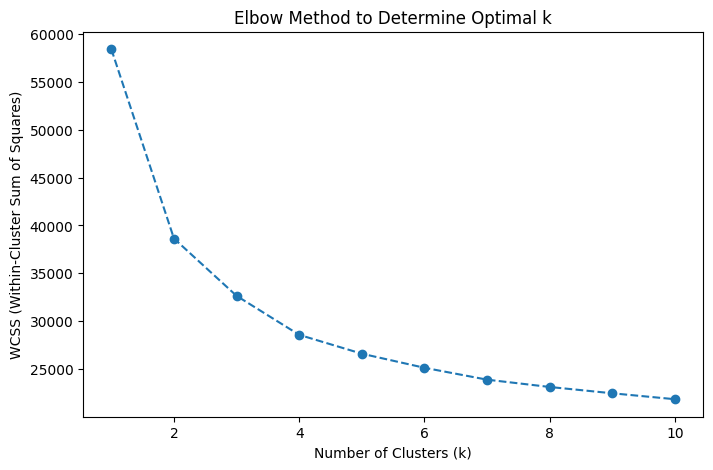

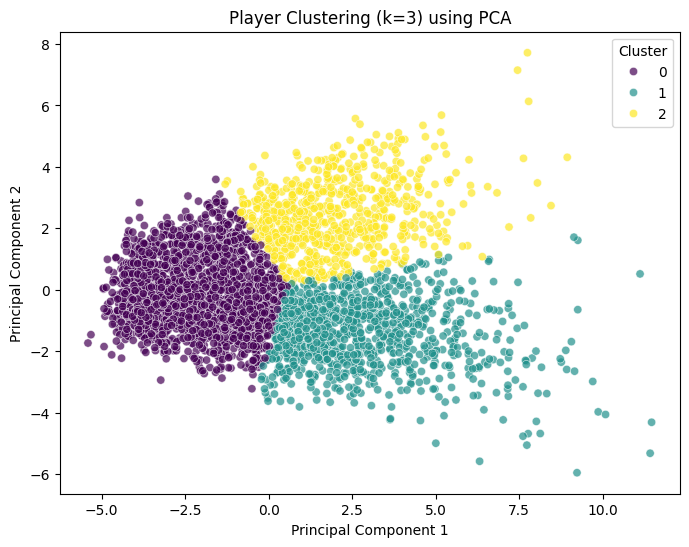

               Tkl       Tkl%    Tkl+Int        Int     Blocks         Clr  \
Cluster                                                                      
0        22.599486  51.476967  35.956298  13.356812  14.871979   28.075578   
1        58.843625  49.047908  88.986056  30.142430  33.098606   42.046813   
2        40.361309  61.668563  74.785206  34.423898  33.877667  101.758179   

           Def 3rd    Mid 3rd       Won%       Lost       Err         Sh  \
Cluster                                                                    
0        11.534704   8.698715  49.528638  14.932134  0.388689   4.961954   
1        27.561753  24.340637  48.836952  27.761952  0.663347   7.638446   
2        25.617354  12.880512  59.847653  37.254623  1.197724  19.485064   

              Pass        Att   Att 3rd        90s      PCA1      PCA2  
Cluster                                                                 
0         9.910026  22.120823  2.366067  13.149049 -2.153013 -0.152222  
1        

In [45]:
# Define features (EXCLUDING 'Rating' since we don't have it)
X = df.drop(columns=['Rating', 'Pos', 'Squad', 'League', 'Season'], errors='ignore')  # Drop 'Rating' if it exists

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method to Determine Optimal k')
plt.show()

# Train K-Means with optimal k (e.g., k=3 based on the elbow curve)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Perform PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Visualize Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue=df['Cluster'], palette='viridis', data=df, alpha=0.7)
plt.title(f'Player Clustering (k={optimal_k}) using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# Display basic statistics of each cluster
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)


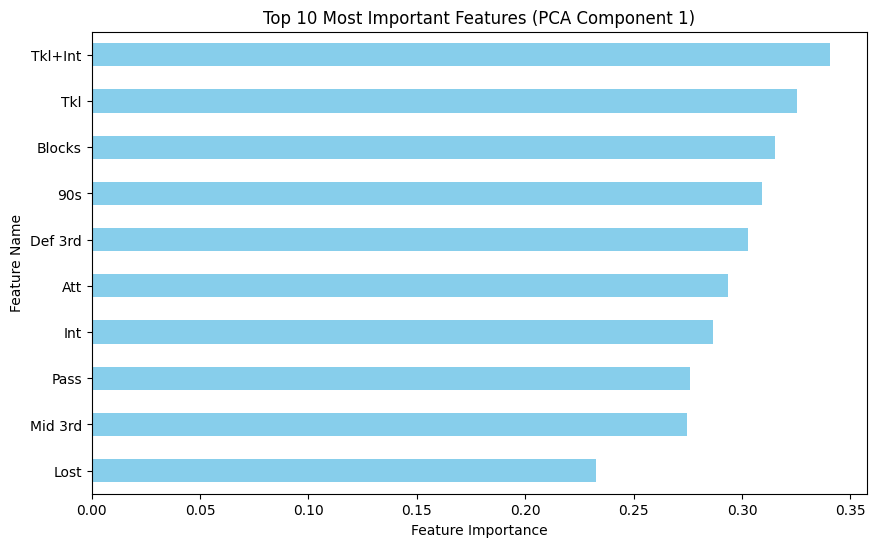

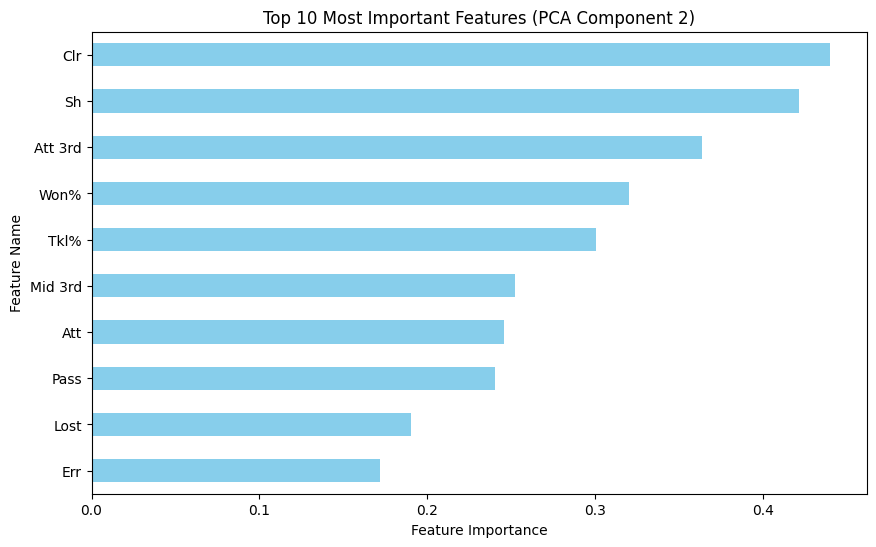

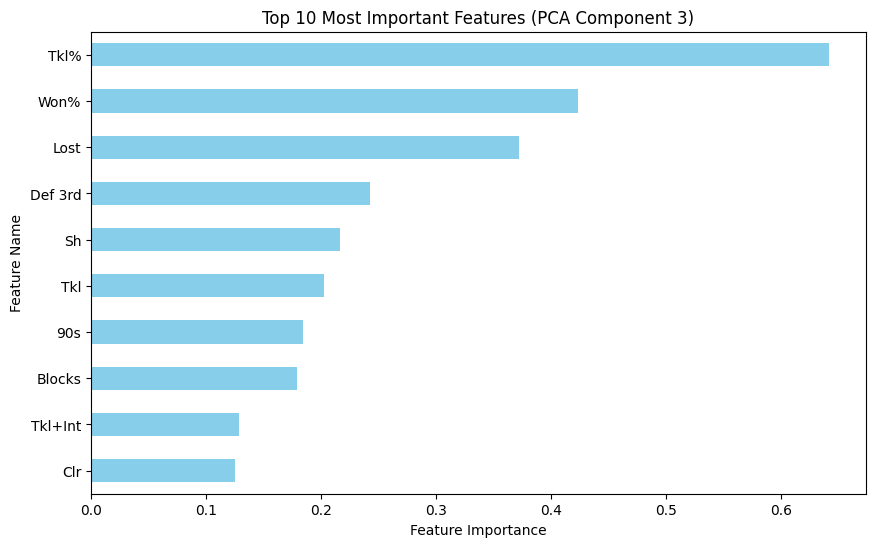

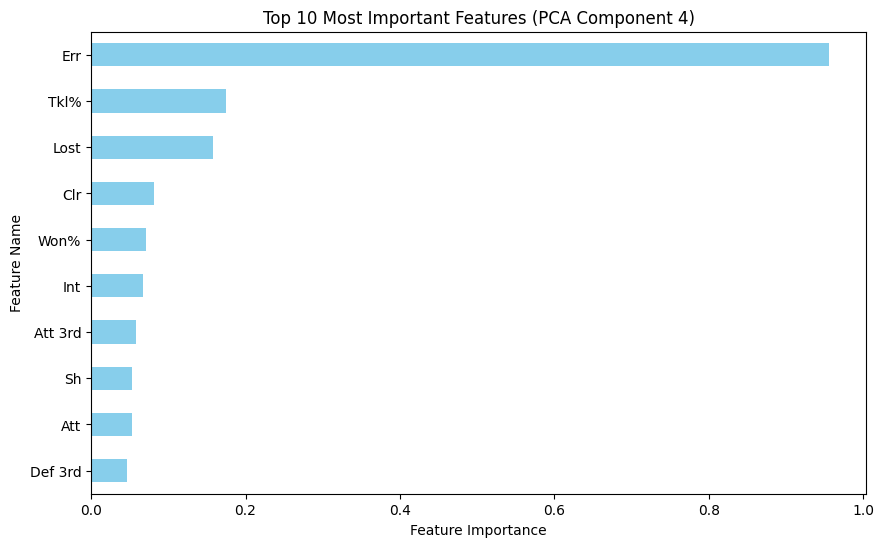

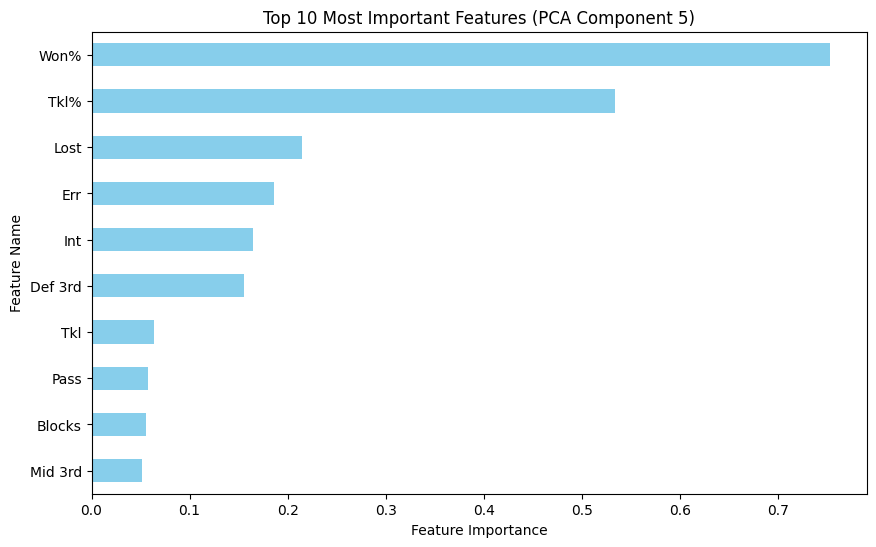

In [47]:
# Standardize features

X = X.drop(columns=['Rating', 'Pos', 'Squad', 'League', 'Season'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=5)  # First 5 components for analysis
X_pca = pca.fit_transform(X_scaled)

# Get PCA loadings (Feature importance)
feature_importance = pd.DataFrame(pca.components_.T, index=X.columns, columns=[f'PC{i+1}' for i in range(5)])

# Plot Top Features for the First Principal Component
for i in range(1, 6):
    plt.figure(figsize=(10,6))
    feature_importance['PC' + str(i)].abs().sort_values(ascending=False)[:10].plot(kind='barh', color='skyblue')
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.title("Top 10 Most Important Features (PCA Component " + str(i) + ")")
    plt.gca().invert_yaxis()
    plt.show()

In [33]:
print(X)

       90s  Tkl  TklW  Def 3rd  Mid 3rd  Att 3rd  Chl-Tkl  Att  Tkl%  \
0     13.7   29    19       20        7        2       20   34  58.8   
1     30.9   64    35       36       23        5       26   45  57.8   
2     16.9   21    14        8       10        3        8   18  44.4   
3     31.8   85    52       43       34        8       38   96  39.6   
4     15.6   25    19       15        9        1       17   34  50.0   
...    ...  ...   ...      ...      ...      ...      ...  ...   ...   
3647  15.7   21    15        9        7        5       11   19  57.9   
3648  23.1   11     6        8        3        0        4    7  57.1   
3649  18.3   20    10       12        8        0       12   18  66.7   
3650  28.8   52    25       19       30        3       22   44  50.0   
3651  25.6   58    33       24       21       13       29   68  42.6   

      Chl-Lost  ...  Squad_Werder Bremen  Squad_West Ham  Squad_Wolfsburg  \
0           14  ...                False           False  

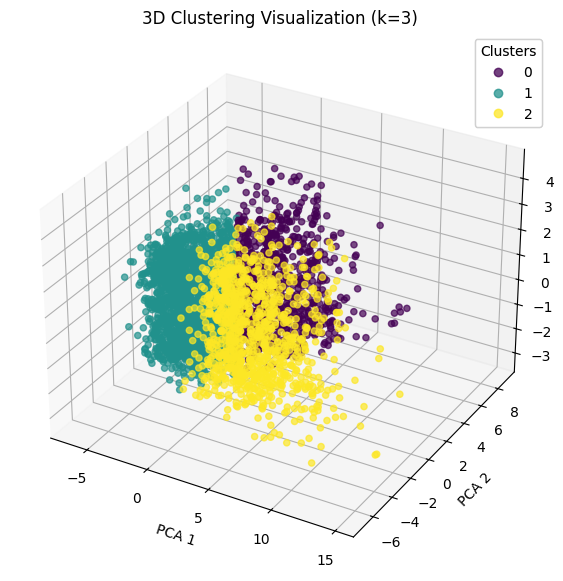

In [30]:
# Perform K-Means clustering
optimal_k = 3  # Adjust based on the elbow method
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Add cluster labels to the dataframe
df['Cluster'] = clusters

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with cluster colors
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, cmap='viridis', alpha=0.7)

# Labels and title
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title(f"3D Clustering Visualization (k={optimal_k})")

# Color legend
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.show()

In [31]:
# Get mean values of each cluster
cluster_summary = df.groupby('Cluster').mean()

# Sort by key defensive features
defensive_features = [
    # 🔹 Core Defensive Actions
    'Tkl', 'Tkl%', 'Tkl+Int', 'Int', 'Blocks', 'Clr',

    # 🔹 Defensive Zone Actions
    'Def 3rd', 'Mid 3rd',

    # 🔹 Possession & Errors
    'Won%', 'Lost', 'Err',

    # 🔹 Other Contributions
    'Sh', 'Pass', 'Att', 'Att 3rd', '90s'
]
defender_clusters = cluster_summary[defensive_features].sort_values(by='Tkl', ascending=False)

print(defender_clusters)

               Tkl       Tkl%    Tkl+Int        Int     Blocks        Clr  \
Cluster                                                                     
2        58.496482  48.308744  88.255276  29.758794  32.807035  41.010050   
0        40.884718  61.478686  75.020107  34.135389  33.310992  98.753351   
1        22.346939  51.695186  35.621141  13.274202  14.903192  28.196232   

           Def 3rd    Mid 3rd       Won%       Lost       Err         Sh  \
Cluster                                                                    
2        27.262312  24.302513  48.330050  27.501508  0.676382   7.455276   
0        25.573727  13.258713  59.893566  36.916890  1.123324  18.782842   
1        11.466248   8.550497  49.539194  14.757718  0.394035   5.017268   

              Pass        Att   Att 3rd        90s  
Cluster                                             
2        25.351759  58.486432  6.931658  26.168643  
0        14.528150  33.857909  2.052279  26.412064  
1         9.885924  2

In [32]:
import pandas as pd

# Cluster summary data
data = {
    'Cluster': [1, 2, 0],
    'Tkl': [58.33, 40.87, 22.31],
    'Tkl%': [48.32, 61.54, 51.71],
    'Tkl+Int': [88.04, 75.06, 35.56],
    'Int': [29.71, 34.20, 13.25],
    'Blocks': [32.74, 33.35, 14.88],
    'Clr': [41.08, 99.06, 28.19],
    'Def 3rd': [27.20, 25.59, 11.45],
    'Mid 3rd': [24.23, 13.24, 8.53],
    'Won%': [48.36, 59.95, 49.54],
    'Lost': [27.48, 36.98, 14.75],
    'Err': [0.67, 1.13, 0.39],
    'Sh': [7.46, 18.86, 5.01],
    'Pass': [25.28, 14.49, 9.87],
    'Att': [58.31, 33.82, 21.67],
    'Att 3rd': [6.90, 2.03, 2.33],
    '90s': [26.14, 26.42, 12.99]
}

# Create DataFrame
df_clusters = pd.DataFrame(data)

# Set 'Cluster' as the index for easier viewing
df_clusters.set_index('Cluster', inplace=True)

# Display the DataFrame
df_clusters


,Tkl,Tkl%,Tkl+Int,Int,Blocks,Clr,Def 3rd,Mid 3rd,Won%,Lost,Err,Sh,Pass,Att,Att 3rd,90s
Cluster,,,,,,,,,,,,,,,,
1,58.33,48.32,88.04,29.71,32.74,41.08,27.20,24.23,48.36,27.48,0.67,7.46,25.28,58.31,6.90,26.14
2,40.87,61.54,75.06,34.20,33.35,99.06,25.59,13.24,59.95,36.98,1.13,18.86,14.49,33.82,2.03,26.42
0,22.31,51.71,35.56,13.25,14.88,28.19,11.45,8.53,49.54,14.75,0.39,5.01,9.87,21.67,2.33,12.99
